# Phép tương quan và minh họa cho ứng dụng radar

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dangquanghieu/tinhieu-hethong-notebooks/blob/main/notebooks/03_phep-tuong-quan-va-radar.ipynb)

Notebook minh họa phép tương quan (correlation) để đo mức độ giống nhau theo độ dịch và ước lượng độ trễ trong một mô hình radar đơn giản.

## Mục tiêu

- Tính tương quan chéo (cross-correlation) của hai dãy có chỉ số thời gian tường minh.
- Nhận biết tương quan chéo là phép chập với một tín hiệu đã lấy liên hợp phức (complex conjugation) và đảo trục thời gian (time reversal).
- Kiểm chứng giá trị tự tương quan (autocorrelation) tại độ trễ không bằng năng lượng tín hiệu.
- Dùng đỉnh tương quan chéo để ước lượng độ trễ và khoảng cách trong mô hình radar có nhiễu.


## Tóm tắt lý thuyết

Tương quan chéo rời rạc đo mức độ giống nhau giữa $x[n]$ và phiên bản dịch của $y[n]$:

$$
r_{xy}[n] := \sum_m x[m]\,y^*[m-n]
= x[n] * y^*[-n].
$$

Vì vậy, khi tính trên mảng hữu hạn, cần lấy liên hợp phức, đảo trục thời gian của dãy thứ hai, rồi dùng phép chập. Tự tương quan là trường hợp $y[n]=x[n]$:

$$
r_{xx}[n] := \sum_m x[m]\,x^*[m-n],
\qquad r_{xx}[0] = E_x := \sum_m |x[m]|^2.
$$

Trong mô hình radar, tín hiệu thu có dạng

$$
y(t) = \alpha x(t-\tau) + n(t),
$$

trong đó $\alpha$ là hệ số suy hao, $\tau$ là thời gian truyền hai chiều và $n(t)$ là nhiễu cộng. Khi bỏ qua nhiễu, $r_{yx}(t)=\alpha r_{xx}(t-\tau)$ có đỉnh tại $t=\tau$. Khoảng cách đến mục tiêu được suy ra từ

$$
R := \frac{c\tau}{2},
$$

với $c$ là tốc độ truyền sóng điện từ.

*Xem thêm: [sách Tín hiệu và hệ thống](https://github.com/dangquanghieu/book-thht), Chương 2 (Hệ thống LTI), mục "Phép tương quan".*


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình trình bày dùng chung cho toàn notebook.
COLORS = {
    "signal": "#0072B2",
    "reference": "#D55E00",
    "result": "#009E73",
    "noise": "#CC79A7",
    "accent": "#E69F00",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def style_discrete(ax, title, xlabel="$n$", ylabel="Biên độ"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="0.35", linewidth=0.8)


def style_continuous(ax, title, xlabel="$t$ [µs]", ylabel="Biên độ"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="0.35", linewidth=0.8)


def stem(ax, n, values, color, label=None):
    markers, stems, baseline = ax.stem(n, values, basefmt=" ")
    markers.set_color(color)
    stems.set_color(color)
    markers.set_label(label)


## Minh họa 1 — Tương quan chéo là phép chập

Hai dãy dưới đây có các gốc thời gian khác nhau. Hình bên trái biểu diễn chúng theo chỉ số thật. Hình bên phải biểu diễn $r_{xy}[n]$; trục của kết quả được tính lại từ các chỉ số đầu-cuối, không mặc định bắt đầu tại $n=0$.


np.convolve và np.correlate cho cùng kết quả: True
Độ trễ tại đỉnh: -1


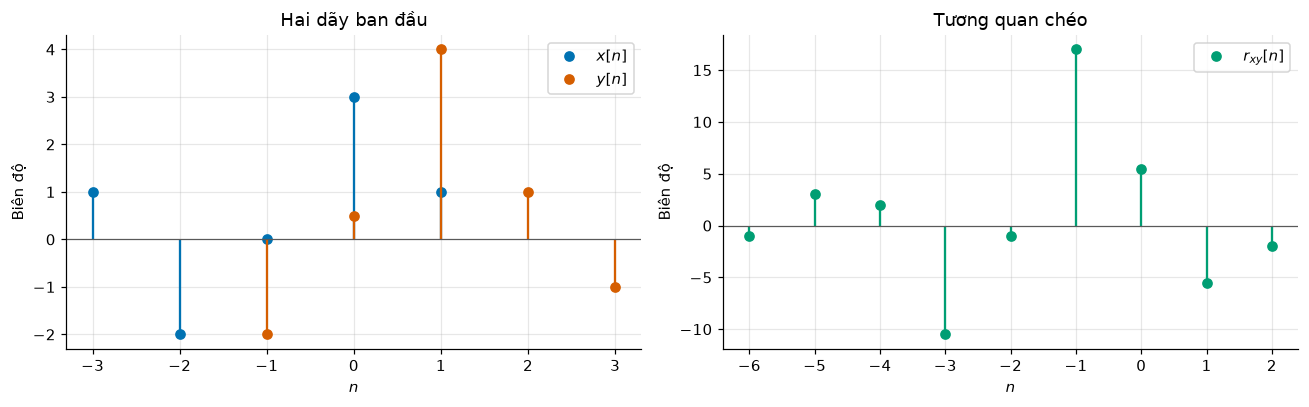

In [2]:
# --- Tạo tín hiệu: mỗi mảng giá trị luôn đi kèm mảng chỉ số ---
nx = np.arange(-3, 2)
x = np.array([1, -2, 0, 3, 1], dtype=float)
ny = np.arange(-1, 4)
y = np.array([-2, 0.5, 4, 1, -1], dtype=float)

# --- Tính toán: r_xy[n] = x[n] * y^*[-n] ---
y_reversed_conjugate = np.conj(y[::-1])
r_xy = np.convolve(x, y_reversed_conjugate)
nr_xy = np.arange(nx[0] - ny[-1], nx[-1] - ny[0] + 1)

# Kiểm chứng với hàm tương quan trực tiếp của NumPy.
r_xy_numpy = np.correlate(x, y, mode="full")
assert np.allclose(r_xy, r_xy_numpy)

# --- Vẽ ---
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
stem(axes[0], nx, x, COLORS["signal"], "$x[n]$")
stem(axes[0], ny, y, COLORS["reference"], "$y[n]$")
style_discrete(axes[0], "Hai dãy ban đầu")
axes[0].legend()

stem(axes[1], nr_xy, r_xy, COLORS["result"], "$r_{xy}[n]$")
style_discrete(axes[1], "Tương quan chéo")
axes[1].legend()
plt.tight_layout()

print("np.convolve và np.correlate cho cùng kết quả:", np.allclose(r_xy, r_xy_numpy))
print("Độ trễ tại đỉnh:", nr_xy[np.argmax(r_xy)])


**Nhận xét.** Phép chập với $y^*[-n]$ và `np.correlate(x, y)` cho cùng dãy kết quả. Đỉnh dương lớn nhất xảy ra tại $n=-1$: khi dịch $y[n]$ sang trái một mẫu, hai dãy giống nhau nhất theo tiêu chuẩn tương quan.

## Minh họa 2 — Tự tương quan và năng lượng

Ta tính tự tương quan của một dãy phức ngắn. Hình sẽ cho thấy đối xứng liên hợp $r_{xx}[-n]=r_{xx}^*[n]$. Giá trị tại độ trễ không được so sánh trực tiếp với năng lượng $E_x$.


E_x = 13.0
r_xx[0] = 13.0+0.0j


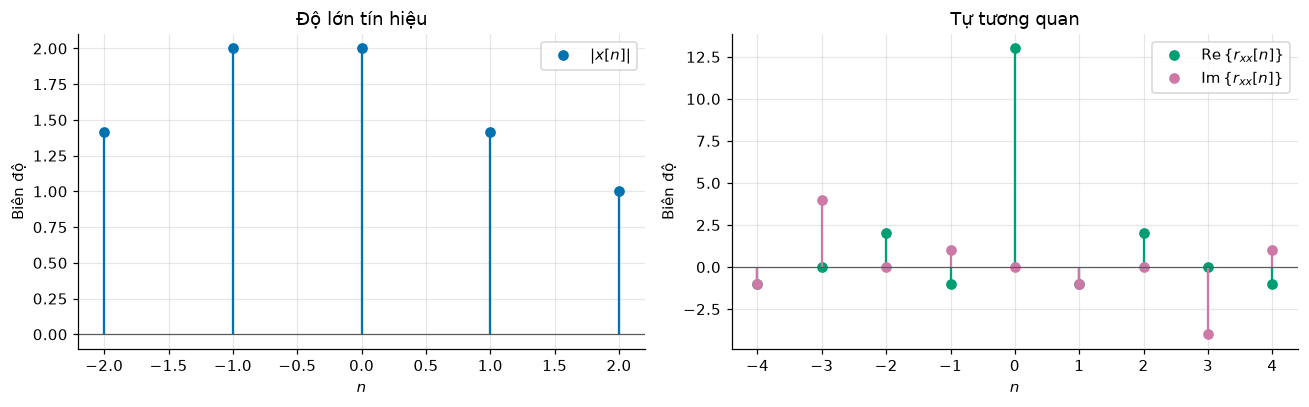

In [3]:
# --- Tạo tín hiệu ---
nx_energy = np.arange(-2, 3)
x_energy = np.array([1 + 1j, -2j, 2, 1 - 1j, -1], dtype=complex)

# --- Tính toán ---
r_xx = np.correlate(x_energy, x_energy, mode="full")
nr_xx = np.arange(nx_energy[0] - nx_energy[-1], nx_energy[-1] - nx_energy[0] + 1)
zero_index = np.flatnonzero(nr_xx == 0)[0]
energy = np.sum(np.abs(x_energy) ** 2)

assert np.allclose(r_xx[zero_index], energy)
assert np.allclose(r_xx, np.conj(r_xx[::-1]))

# --- Vẽ ---
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
stem(axes[0], nx_energy, np.abs(x_energy), COLORS["signal"], "$|x[n]|$")
style_discrete(axes[0], "Độ lớn tín hiệu")
axes[0].legend()

stem(axes[1], nr_xx, r_xx.real, COLORS["result"], r"$\operatorname{Re}\{r_{xx}[n]\}$")
stem(axes[1], nr_xx, r_xx.imag, COLORS["noise"], r"$\operatorname{Im}\{r_{xx}[n]\}$")
style_discrete(axes[1], "Tự tương quan")
axes[1].legend()
plt.tight_layout()

print(f"E_x = {energy:.1f}")
print(f"r_xx[0] = {r_xx[zero_index]:.1f}")


**Nhận xét.** Giá trị $r_{xx}[0]$ đúng bằng $E_x$. Với tín hiệu phức, phần ảo của tự tương quan thường không bằng không, nhưng đồ thị vẫn có đối xứng liên hợp qua gốc. Nếu tín hiệu là thực, tự tương quan là một hàm thực chẵn.

## Minh họa 3 — Ước lượng độ trễ trong radar

Radar phát một xung hình sin dài $T=20$ µs. Tín hiệu thu là bản sao bị suy hao, trễ $\tau=8{,}8$ µs và có nhiễu trắng Gauss (white Gaussian noise). Tỉ lệ thời gian được chọn để có thể minh họa trực quan; khi đổi sang giây, công thức $R=c\tau/2$ vẫn cho khoảng cách vật lý.


Độ trễ thực:       8.8 µs
Độ trễ ước lượng:  8.8 µs
Khoảng cách thực:  1.319 km
Khoảng cách ước lượng: 1.319 km


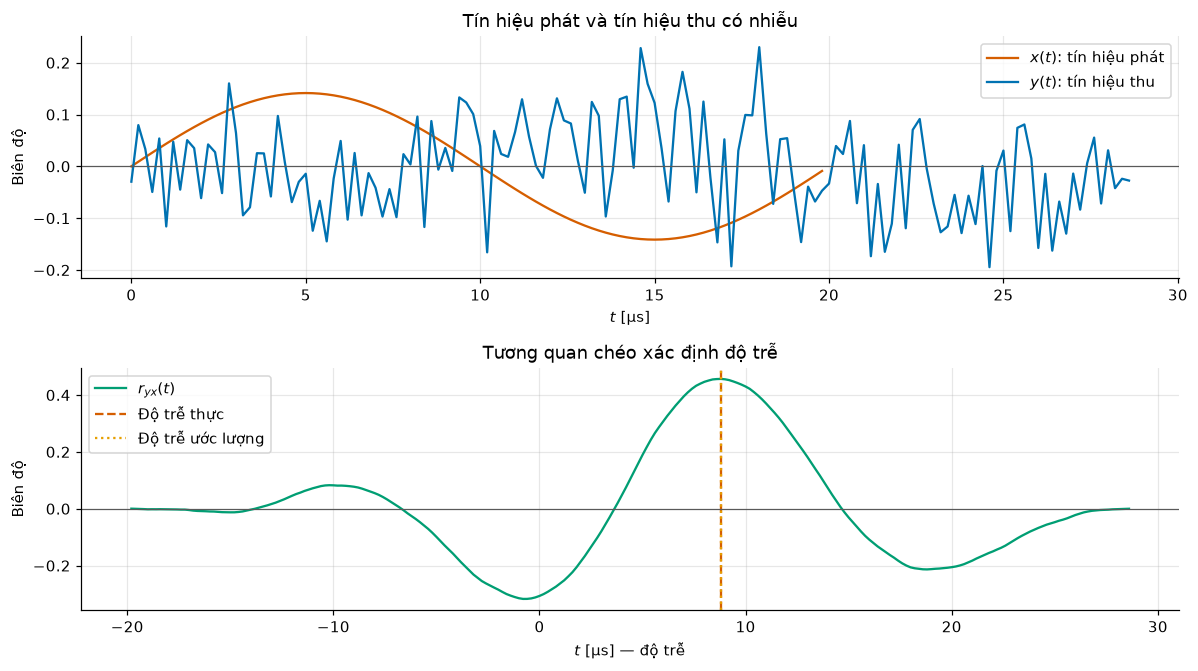

In [4]:
# --- Tạo tín hiệu phát và tín hiệu thu ---
T_us = 20.0
dt_us = 0.2
t_tx_us = np.arange(0.0, T_us, dt_us)
pulse = np.sin(2 * np.pi * t_tx_us / T_us)
pulse = pulse / np.linalg.norm(pulse)

delay_samples = 44
tau_true_us = delay_samples * dt_us
alpha = 0.35
t_rx_us = np.arange(0, delay_samples + pulse.size) * dt_us

rng = np.random.default_rng(19)
noise_std = 0.08
noise = noise_std * rng.standard_normal(t_rx_us.size)
received = noise.copy()
received[delay_samples : delay_samples + pulse.size] += alpha * pulse

# --- Tính tương quan chéo và ước lượng ---
r_yx = np.correlate(received, pulse, mode="full")
lag_samples = np.arange(-(pulse.size - 1), received.size)
lag_us = lag_samples * dt_us
tau_est_us = lag_us[np.argmax(np.abs(r_yx))]

c = 299_792_458.0  # m/s
range_est_m = c * tau_est_us * 1e-6 / 2
range_true_m = c * tau_true_us * 1e-6 / 2

# --- Vẽ ---
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=False)
axes[0].plot(t_tx_us, pulse, color=COLORS["reference"], label="$x(t)$: tín hiệu phát")
axes[0].plot(t_rx_us, received, color=COLORS["signal"], label="$y(t)$: tín hiệu thu")
style_continuous(axes[0], "Tín hiệu phát và tín hiệu thu có nhiễu")
axes[0].legend(loc="upper right")

axes[1].plot(lag_us, r_yx, color=COLORS["result"], label="$r_{yx}(t)$")
axes[1].axvline(tau_true_us, color=COLORS["reference"], linestyle="--", label="Độ trễ thực")
axes[1].axvline(tau_est_us, color=COLORS["accent"], linestyle=":", label="Độ trễ ước lượng")
style_continuous(axes[1], "Tương quan chéo xác định độ trễ")
axes[1].set_xlabel("$t$ [µs] — độ trễ")
axes[1].legend(loc="upper left")
plt.tight_layout()

print(f"Độ trễ thực:       {tau_true_us:.1f} µs")
print(f"Độ trễ ước lượng:  {tau_est_us:.1f} µs")
print(f"Khoảng cách thực:  {range_true_m / 1e3:.3f} km")
print(f"Khoảng cách ước lượng: {range_est_m / 1e3:.3f} km")


**Nhận xét.** Trên đồ thị tín hiệu thu, xung suy hao bị nhiễu che lấp một phần. Tuy nhiên, tương quan chéo tích lũy mức độ khớp của toàn bộ dạng sóng nên tạo một đỉnh rõ tại độ trễ. Trong lần chạy này, độ trễ ước lượng trùng với độ trễ thực; với mức nhiễu cao hơn, đỉnh có thể lệch hoặc không còn phân biệt rõ.

## Câu hỏi suy ngẫm

1. Vì sao tương quan chéo cần liên hợp phức khi tín hiệu là số phức?
2. Nếu tăng độ dài của xung phát nhưng giữ cùng mức nhiễu, đỉnh tương quan thay đổi như thế nào?
3. Nếu có hai mục tiêu ở hai khoảng cách khác nhau, đồ thị tương quan chéo có dạng gì?
4. Tại sao khoảng cách trong radar được chia cho $2$?
